Ćwiczenie 1: Implementacja podstawowego modelu baggingu

Wczytaj zbiór danych Breast Cancer (https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) i podziel go na zbiór treningowy oraz testowy (np. w proporcji 70:30).
Wytrenuj pojedyncze drzewo decyzyjne (DecisionTreeClassifier) na zbiorze treningowym i oblicz jego dokładność na zbiorze testowym.
Wytrenuj BaggingClassifier z n_estimators=10, używając jako bazowy model DecisionTreeClassifier. Porównaj jego dokładność z pojedynczym drzewem decyzyjnym.
Czy bagging poprawił wyniki? Jakie są różnice?

In [58]:
# Import bibliotek
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets.squeeze()

# 2. Podział na zbiór treningowy i testowy (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3
)

# 3. Trenowanie pojedynczego drzewa decyzyjnego
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

# Predykcja
y_pred_tree = tree.predict(X_test)

# Dokładność
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Dokładność pojedynczego drzewa:", accuracy_tree)

# 4. Trenowanie modelu Bagging
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=10,
)

bagging.fit(X_train, y_train)

# Predykcja
y_pred_bag = bagging.predict(X_test)

# Dokładność
accuracy_bag = accuracy_score(y_test, y_pred_bag)

print("Dokładność Bagging:", accuracy_bag)

# 5. Porównanie wyników
print("\nPorównanie:")
print("Drzewo decyzyjne:", accuracy_tree)
print("Bagging:", accuracy_bag)
print("Różnica:", accuracy_bag - accuracy_tree)

if accuracy_bag > accuracy_tree:
    print("Bagging poprawił wyniki.")
elif accuracy_bag < accuracy_tree:
    print("Bagging dał gorsze wyniki.")
else:
    print("Wyniki są takie same.")

Dokładność pojedynczego drzewa: 0.9239766081871345
Dokładność Bagging: 0.935672514619883

Porównanie:
Drzewo decyzyjne: 0.9239766081871345
Bagging: 0.935672514619883
Różnica: 0.011695906432748537
Bagging poprawił wyniki.


Ćwiczenie 2: Wpływ liczby estymatorów w baggingu

Wykorzystaj ten sam zbiór danych i BaggingClassifier.
Przetestuj różne wartości n_estimators (np. 5, 10, 50, 100) i dla każdej wartości oblicz dokładność modelu na zbiorze testowym.
Narysuj wykres zależności n_estimators od dokładności modelu.
W którym momencie dodanie kolejnych estymatorów przestaje przynosić korzyści?

n_estimators=5 -> dokładność=0.9181
n_estimators=10 -> dokładność=0.9123
n_estimators=15 -> dokładność=0.9181
n_estimators=20 -> dokładność=0.9181
n_estimators=25 -> dokładność=0.9240
n_estimators=30 -> dokładność=0.9298
n_estimators=35 -> dokładność=0.9298
n_estimators=40 -> dokładność=0.9298
n_estimators=45 -> dokładność=0.9298
n_estimators=50 -> dokładność=0.9298
n_estimators=55 -> dokładność=0.9298
n_estimators=60 -> dokładność=0.9298
n_estimators=65 -> dokładność=0.9298
n_estimators=70 -> dokładność=0.9240
n_estimators=75 -> dokładność=0.9298
n_estimators=80 -> dokładność=0.9298
n_estimators=85 -> dokładność=0.9298
n_estimators=90 -> dokładność=0.9298
n_estimators=95 -> dokładność=0.9298
n_estimators=100 -> dokładność=0.9298
n_estimators=105 -> dokładność=0.9298
n_estimators=110 -> dokładność=0.9298
n_estimators=115 -> dokładność=0.9298
n_estimators=120 -> dokładność=0.9298
n_estimators=125 -> dokładność=0.9298
n_estimators=130 -> dokładność=0.9298
n_estimators=135 -> dokładność=0

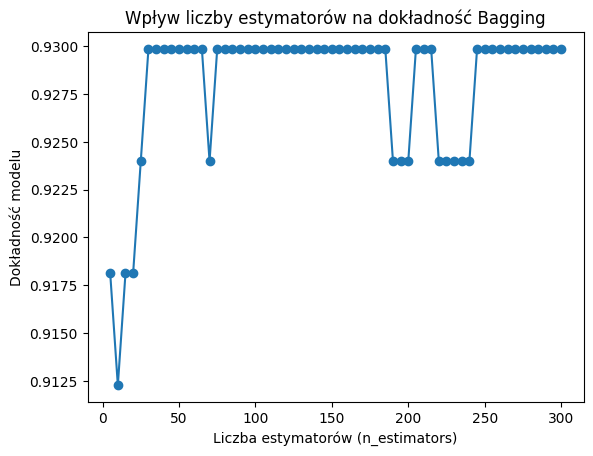

In [59]:
from matplotlib import pyplot as plt

n_estimators_list = list(range(5, 301, 5))

accuracies = []

for n in n_estimators_list:
    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"n_estimators={n} -> dokładność={acc:.4f}")


plt.figure()
plt.plot(n_estimators_list, accuracies, marker='o')
plt.xlabel("Liczba estymatorów (n_estimators)")
plt.ylabel("Dokładność modelu")
plt.title("Wpływ liczby estymatorów na dokładność Bagging")
plt.show()

Ćwiczenie 3: Bagging vs Random Forest

Używając tego samego zbioru danych, wytrenuj model RandomForestClassifier z n_estimators=50.
Porównaj jego dokładność z modelem BaggingClassifier (również n_estimators=50).
Który model ma lepszą dokładność? Jakie mogą być przyczyny tej różnicy?

In [65]:
from sklearn.ensemble import RandomForestClassifier

# Bagging
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
)

bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)
bag_acc = accuracy_score(y_test, y_pred_bag)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=50,
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Bagging accuracy:", bag_acc)
print("Random Forest accuracy:", rf_acc)

Bagging accuracy: 0.9181286549707602
Random Forest accuracy: 0.935672514619883


Model Random Forest osiągnął wyższą dokładność (0.9357) niż model Bagging (0.9181). Oznacza to, że w tym przypadku Random Forest lepiej radzi sobie z klasyfikacją danych.

Jedną z przyczyn tej różnicy jest to, że Random Forest oprócz losowego próbkowania danych wykorzystuje również losowy wybór cech przy budowie drzew. Dzięki temu drzewa w lesie są bardziej zróżnicowane i mniej ze sobą skorelowane, co poprawia zdolność modelu do generalizacji.

Ćwiczenie 4: Eksperyment z innym bazowym modelem

Wykorzystaj SVM (SVC) jako bazowy model zamiast drzewa decyzyjnego w BaggingClassifier.
Porównaj wyniki baggingu z SVM oraz baggingu z drzewami decyzyjnymi.
Która kombinacja działa lepiej? Dlaczego?

In [69]:
from sklearn.svm import SVC

# Bagging z drzewami
bag_tree = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag_tree.fit(X_train, y_train)
pred_tree = bag_tree.predict(X_test)
acc_tree = accuracy_score(y_test, pred_tree)

print("Bagging + Decision Tree:", acc_tree)

# Bagging z SVM
bag_svm = BaggingClassifier(
    estimator=SVC(),
    n_estimators=50,
    random_state=42
)

bag_svm.fit(X_train, y_train)
pred_svm = bag_svm.predict(X_test)
acc_svm = accuracy_score(y_test, pred_svm)

print("Bagging + SVM:", acc_svm)

Bagging + Decision Tree: 0.9298245614035088
Bagging + SVM: 0.8596491228070176


Dzieje się tak dlatego, że drzewa decyzyjne mają wysoką wariancję, więc bardzo korzystają z metody bagging, która redukuje wariancję poprzez trenowanie wielu modeli na różnych próbkach danych. SVM natomiast jest modelem bardziej stabilnym (ma niższą wariancję), dlatego bagging zwykle nie poprawia jego wyników w tak dużym stopniu.

Ćwiczenie 5: Analiza wpływu losowości w baggingu

Eksperyment z losowymi podziałami danych
Powtórz eksperyment z BaggingClassifier, ale zmieniaj wartość random_state (np. 0, 42, 100, 1234).
Czy model zawsze osiąga podobną dokładność? Jak bardzo wyniki się różnią?
Jakie mogą być przyczyny tych różnic?
Analiza wpływu głębokości drzew decyzyjnych
W modelu BaggingClassifier ustaw estimator=DecisionTreeClassifier(max_depth=3) i porównaj wyniki z modelem, który ma max_depth=None (pełne drzewa).
Jak zmienia się dokładność?

In [72]:
states = [0, 42, 100, 1234, 2137 ]

for s in states:
    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=50,
        random_state=s
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    print(f"random_state={s}, accuracy={acc}")

random_state=0, accuracy=0.9239766081871345
random_state=42, accuracy=0.9298245614035088
random_state=100, accuracy=0.9181286549707602
random_state=1234, accuracy=0.9181286549707602
random_state=2137, accuracy=0.9181286549707602


Po zmianie wartości random_state dokładność modelu zwykle jest bardzo podobna, ale może się nieznacznie różnić. Różnice są zazwyczaj niewielkie (np. 1–2%).

Dzieje się tak dlatego, że Bagging wykorzystuje losowe próbkowanie danych (bootstrap sampling) do trenowania poszczególnych modeli. Zmiana random_state powoduje powstanie innych zestawów próbek treningowych, co może prowadzić do niewielkich zmian w wynikach.

In [77]:
# płytkie drzewa
model_shallow = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    random_state=42
)

model_shallow.fit(X_train, y_train)
pred_shallow = model_shallow.predict(X_test)
acc_shallow = accuracy_score(y_test, pred_shallow)

# pełne drzewa
model_full = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=50,
    random_state=42
)

model_full.fit(X_train, y_train)
pred_full = model_full.predict(X_test)
acc_full = accuracy_score(y_test, pred_full)

print("Shallow trees accuracy:", acc_shallow)
print("Full trees accuracy:", acc_full)

Shallow trees accuracy: 0.9239766081871345
Full trees accuracy: 0.9298245614035088


Modele z pełnymi drzewami (max_depth=None) często osiągają wyższą dokładność niż modele z płytkimi drzewami (max_depth=3). Wynika to z tego, że głębsze drzewa mogą lepiej dopasować się do złożonych zależności w danych.